## Khởi tạo kết nối và kiểm tra dữ liệu trên HDFS
### 1. Mục tiêu:
* Thiết lập kết nối giữa cụm tính toán phân tán Apache Spark và hệ thống lưu trữ phân tán HDFS (NameNode).
* Thực hiện quét song song (Parallel Scan) để kiểm tra tính toàn vẹn đếm tổng số lượng tệp tin ảnh nhị phân (`binaryFile`) đã được nạp thành công ở Bước 5.
* Khảo sát cấu trúc lược đồ (Schema) mặc định của dữ liệu thô.

In [1]:
from pyspark.sql import SparkSession

#Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("PlantDisease_BigData_Local_Processing") \
    .master("local[*]") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("=========================================================================")
spark.sparkContext.setLogLevel("ERROR") 
print("        HỆ THỐNG APPACHE SPARK LOCAL ĐÃ KẾT NỐI HADOOP THÀNH CÔNG        ")
print("=========================================================================")

#Đọc cấu trúc tệp nhị phân từ Hadoop HDFS 
hdfs_path = "hdfs://namenode:9000/user/bigdata/dpd/raw"
raw_files_df = spark.read.format("binaryFile") \
    .option("recursiveFileLookup", "true") \
    .load(hdfs_path)

#Tiến hành đếm tổng số lượng ảnh màu phân tán
total_images = raw_files_df.count()
print(f"--> TỔNG SỐ LƯỢNG FILE ẢNH MÀU HOÀN CHỈNH TRÊN HADOOP: {total_images} ẢNH")
print("=========================================================================")

#Hiển thị cấu trúc Schema
raw_files_df.printSchema()

        HỆ THỐNG APPACHE SPARK LOCAL ĐÃ KẾT NỐI HADOOP THÀNH CÔNG        
--> TỔNG SỐ LƯỢNG FILE ẢNH MÀU HOÀN CHỈNH TRÊN HADOOP: 52116 ẢNH
root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)



### Tiền xử lý dữ liệu (Preprocessing) & Trích xuất Nhãn (Label Extraction)

Tại đây, ta sẽ thực hiện hai tác vụ xử lý dữ liệu bằng Apache Spark:
1. Dựa vào cấu trúc đường dẫn lưu trữ trên HDFS (`hdfs://namenode:9000/user/bigdata/dpd/raw/[Tên_Nhãn]/[Tên_Ảnh].jpg`), ta sử dụng các hàm xử lý chuỗi phân tán (`regexp_extract`) để bóc tách tên thư mục con làm nhãn bệnh cho từng bức ảnh.
2. Gom danh sách 52.116 tệp ảnh đơn lẻ thành một DataFrame có cấu trúc gọn gàng bao gồm hai cột chính: `label` (Nhãn chuỗi văn bản) và `content` (Dữ liệu nhị phân của ảnh).

In [2]:
from pyspark.sql.functions import regexp_extract, col

print("=========================================================================")
print("             BẮT ĐẦU QUY TRÌNH TIỀN XỬ LÝ & TRÍCH XUẤT NHÃN              ")
print("=========================================================================")

#Bóc tách tên thư mục bệnh từ cột 'path'
regex_pattern = r".*/raw/([^/]+)/[^/]+$"

processed_df = raw_files_df.select(
    regexp_extract(col("path"), regex_pattern, 1).alias("label"),
    col("content")
)

#Hiển thị thử nghiệm 5 dòng đầu tiên sau khi trích xuất nhãn để kiểm tra
print("Cấu trúc 5 dòng dữ liệu đầu tiên sau khi bóc tách nhãn:")
processed_df.show(5, truncate=40)

#Thống kê nhanh danh sách các lớp (nhãn bệnh) và số lượng ảnh tương ứng của từng lớp
print("Thống kê phân phối số lượng dữ liệu trên từng nhãn bệnh...")
label_counts = processed_df.groupBy("label").count().orderBy("label")

#Hiển thị toàn bộ các nhãn bệnh quét được
label_counts.show(label_counts.count(), truncate=False)
print("=========================================================================")

             BẮT ĐẦU QUY TRÌNH TIỀN XỬ LÝ & TRÍCH XUẤT NHÃN              
Cấu trúc 5 dòng dữ liệu đầu tiên sau khi bóc tách nhãn:
+---------------------------------+----------------------------------------+
|                            label|                                 content|
+---------------------------------+----------------------------------------+
|           Pepper,_bell___healthy|[89 50 4E 47 0D 0A 1A 0A 00 00 00 0D ...|
|Cherry_(including_sour)___healthy|[FF D8 FF E0 00 10 4A 46 49 46 00 01 ...|
|                 Tomato___healthy|[FF D8 FF E0 00 10 4A 46 49 46 00 01 ...|
|                 Tomato___healthy|[FF D8 FF E0 00 10 4A 46 49 46 00 01 ...|
|                 Tomato___healthy|[FF D8 FF E0 00 10 4A 46 49 46 00 01 ...|
+---------------------------------+----------------------------------------+
only showing top 5 rows

Thống kê phân phối số lượng dữ liệu trên từng nhãn bệnh...
+------------------------------------------+-----+
|label                                    

In [3]:
print("=========================================================================")
print("            ĐANG TIẾN HÀNH LƯU TRỮ DỮ LIỆU SANG ĐỊNH DẠNG PARQUET         ")
print("=========================================================================")

#Đường dẫn lưu trữ tệp đã qua xử lý trên HDFS
output_hdfs_path = "hdfs://namenode:9000/user/bigdata/dpd/processed_data.parquet"

try:
    #Ghi đè (overwrite) dữ liệu dưới dạng parquet nén phân tán
    processed_df.write.mode("overwrite").parquet(output_hdfs_path)
    print(f"Lưu dữ liệu thành công dưới dạng file parquet: {output_hdfs_path}")
    
    print("\nKiểm tra thử việc đọc lại tệp Parquet vừa lưu:")
    parquet_check_df = spark.read.parquet(output_hdfs_path)
    print(f"Tổng số lượng bản ghi đọc lại từ tệp Parquet: {parquet_check_df.count()} dòng.")
    parquet_check_df.printSchema()

except Exception as e:
    print("Có lỗi xảy ra:")
    print(e)

print("=========================================================================")

            ĐANG TIẾN HÀNH LƯU TRỮ DỮ LIỆU SANG ĐỊNH DẠNG PARQUET         
Lưu dữ liệu thành công dưới dạng file parquet: hdfs://namenode:9000/user/bigdata/dpd/processed_data.parquet

Kiểm tra thử việc đọc lại tệp Parquet vừa lưu:
Tổng số lượng bản ghi đọc lại từ tệp Parquet: 52116 dòng.
root
 |-- label: string (nullable = true)
 |-- content: binary (nullable = true)



### EDA (Exploratory Data Analyst) & Trực quan hóa hình ảnh

1. Chuyển đổi bảng thống kê phân tán của Spark sang Pandas DataFrame để vẽ biểu đồ thanh (Bar Chart), trực quan hóa phân phối số lượng ảnh trên từng nhãn bệnh.
2. Trích xuất ngẫu nhiên dữ liệu nhị phân từ tệp Parquet, sử dụng thư viện `PIL (Pillow)` và `matplotlib` để giải mã (decode) chuỗi byte thành hình ảnh trực quan, đảm bảo chất lượng hình ảnh không bị biến đổi trong quá trình lưu trữ phân tán.

#### Trực quan hóa vĩ mô (Phân phối nhãn)

1. Nhiệm vụ: Vẽ biểu đồ thanh hiển thị số lượng ảnh của từng loại bệnh.

2. Mục tiêu: Xác định xem tập dữ liệu 52.116 ảnh này có bị mất cân bằng (Class Imbalance) hay không.

                   TẠO BIỂU ĐỒ PHÂN PHỐI NHÃN BỆNH (EDA)                 


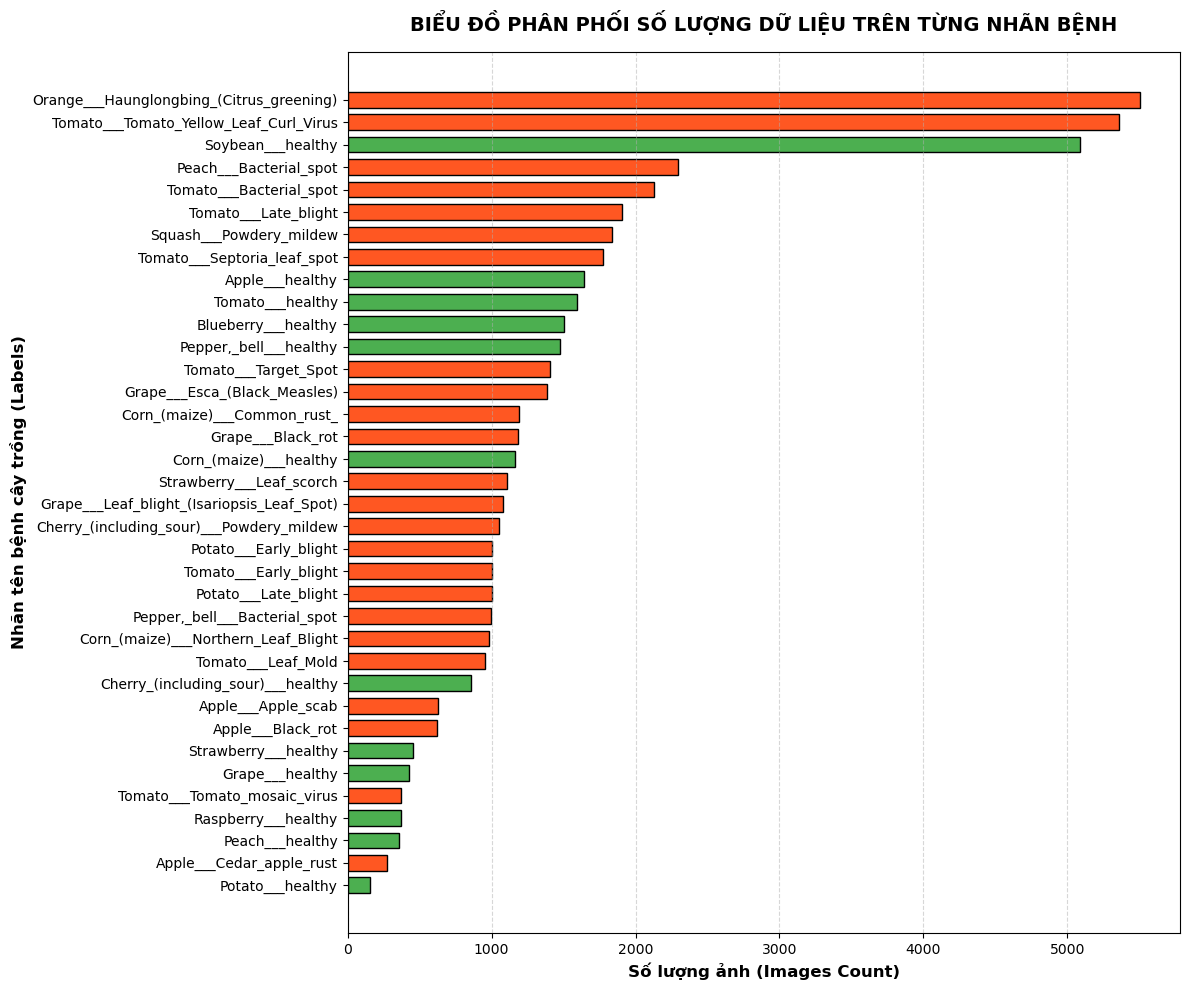

==> Tổng số lượng lớp bệnh cây trồng quét được: 36 lớp.


In [4]:
import matplotlib.pyplot as plt
import pandas as plt_pandas

print("=========================================================================")
print("                   TẠO BIỂU ĐỒ PHÂN PHỐI NHÃN BỆNH (EDA)                 ")
print("=========================================================================")

#Đọc dữ liệu từ tệp Parquet
parquet_df = spark.read.parquet("hdfs://namenode:9000/user/bigdata/dpd/processed_data.parquet")

#Gom nhóm, đếm số lượng để phục vụ vẽ biểu đồ
pdf = parquet_df.groupBy("label").count().orderBy("count", ascending=False).toPandas()

#Cấu hình vẽ biểu đồ (Horizontal Bar Chart)
plt.figure(figsize=(12, 10))
colors = ['#4CAF50' if 'healthy' in l else '#FF5722' for l in pdf['label']] # Màu xanh cho cây khỏe, màu cam cho cây bệnh

plt.barh(pdf['label'], pdf['count'], color=colors, edgecolor='black', height=0.7)
plt.xlabel('Số lượng ảnh (Images Count)', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn tên bệnh cây trồng (Labels)', fontsize=12, fontweight='bold')
plt.title('BIỂU ĐỒ PHÂN PHỐI SỐ LƯỢNG DỮ LIỆU TRÊN TỪNG NHÃN BỆNH', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"==> Tổng số lượng lớp bệnh cây trồng quét được: {len(pdf)} lớp.")
print("=========================================================================")

#### Nghiệm thu vi mô (Giải mã ảnh mẫu)

1. Nhiệm vụ: Bốc ngẫu nhiên 3 ảnh nhị phân từ file Parquet và hiển thị lên màn hình.

2. Mục tiêu đồ án: Chứng minh dữ liệu lưu trên HDFS không bị lỗi, ảnh giải mã ra vẫn nguyên vẹn sắc nét.

          ĐANG TRÍCH XUẤT VÀ GIẢI MÃ HIỂN THỊ ẢNH MẪU TỪ HDFS            


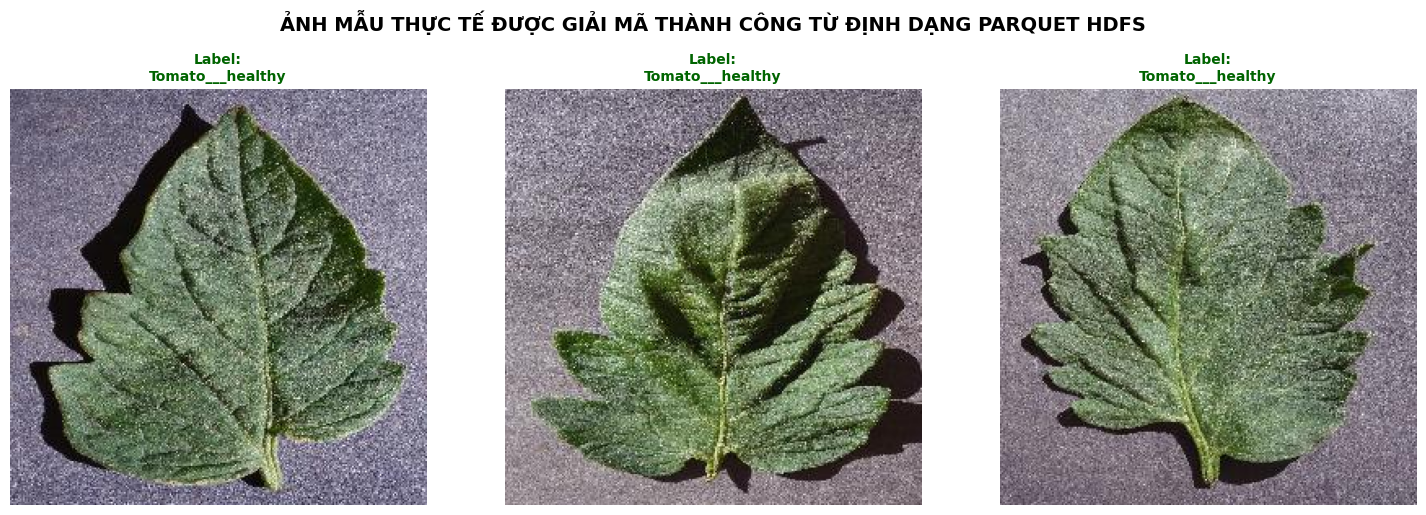

In [5]:
import io
from PIL import Image
import matplotlib.pyplot as plt

print("=========================================================================")
print("          ĐANG TRÍCH XUẤT VÀ GIẢI MÃ HIỂN THỊ ẢNH MẪU TỪ HDFS            ")
print("=========================================================================")

# Lấy ngẫu nhiên 3 dòng dữ liệu (mỗi dòng đại diện cho một ảnh)
sample_rows = parquet_df.sample(withReplacement=False, fraction=0.01, seed=42).limit(3).collect()

#Khởi tạo khung hiển thị đồ họa matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, row in enumerate(sample_rows):
    label_name = row['label']
    binary_data = row['content']
    
    # Giải mã mảng byte nhị phân thành đối tượng hình ảnh PIL Image
    image_stream = io.BytesIO(binary_data)
    img = Image.open(image_stream)
    
    #Vẽ ảnh lên ô biểu đồ tương ứng
    axes[i].imshow(img)
    #Cắt ngắn tiêu đề nếu tên nhãn bệnh quá dài
    axes[i].set_title(f"Label:\n{label_name}", fontsize=10, fontweight='bold', color='darkgreen')
    axes[i].axis('off') 

plt.suptitle("ẢNH MẪU THỰC TẾ ĐƯỢC GIẢI MÃ THÀNH CÔNG TỪ ĐỊNH DẠNG PARQUET HDFS", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("=========================================================================")

#### Phân tích Thuộc tính Vật lý (Kích thước ảnh)
1. Nhiệm vụ: Thống kê xem ảnh có cùng kích thước $256 \times 256$ không, hay có ảnh nào bị lệch tỷ lệ (Aspect Ratio).
2. Mục tiêu đồ án: Làm tiền đề để đưa ra quyết định cấu hình lớp Resize ảnh khi thiết kế mạng CNN ở bước Train Model.

In [6]:
import io
from PIL import Image
from pyspark.sql.functions import expr
from pyspark.sql.types import StructType, StructField, IntegerType

print("=========================================================================")
print("===       ĐANG THỐNG KÊ KÍCH THƯỚC HÌNH ẢNH CHUẨN XÁC BẰNG PIL        ===")
print("=========================================================================")

#Định nghĩa hàm Python sử dụng PIL
def get_image_dimensions_pil(binary_data):
    try:
        with Image.open(io.BytesIO(binary_data)) as img:
            w, h = img.size
            return int(w), int(h)
    except:
        return None, None

#Cấu trúc Schema và UDF 
dim_schema = StructType([
    StructField("width", IntegerType(), True),
    StructField("height", IntegerType(), True)
])
spark.udf.register("get_dims_pil", get_image_dimensions_pil, dim_schema)

#Trích xuất và tính toán thống kê kích thước
meta_df = parquet_df.withColumn("dims", expr("get_dims_pil(content)")) \
                    .select("label", "dims.width", "dims.height")

#Hiển thị bảng kết quả 
meta_df.groupBy("width", "height").count().show()
print("=========================================================================")

===       ĐANG THỐNG KÊ KÍCH THƯỚC HÌNH ẢNH CHUẨN XÁC BẰNG PIL        ===
+-----+------+-----+
|width|height|count|
+-----+------+-----+
|  256|   256|52116|
+-----+------+-----+



#### Phân tích Hạ tầng Big Data (Dung lượng file)

1. Nhiệm vụ: Vẽ biểu đồ Boxplot thống kê phân phối dung lượng (KB) của 52.116 tệp.

2. Mục tiêu đồ án: Tìm ra các file dị biệt (quá nhỏ hoặc quá lớn) để kiểm soát chất lượng dữ liệu đầu vào.

=== THỐNG KÊ DUNG LƯỢNG FILE (FILE SIZE ANALYSIS) ===


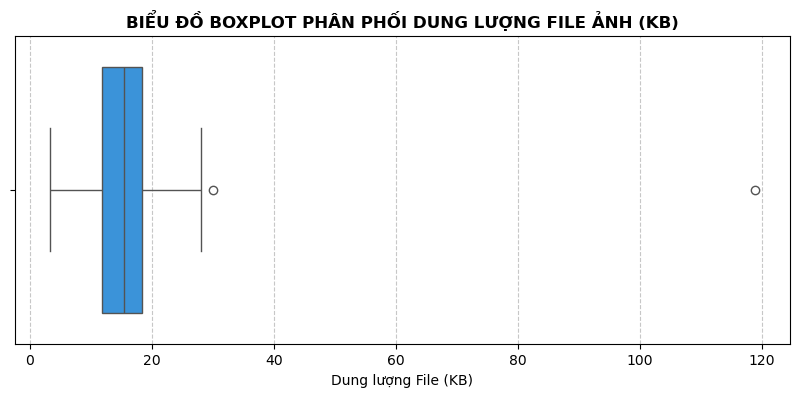

+-------+------------------+
|summary|           size_kb|
+-------+------------------+
|  count|             52116|
|   mean|15.165628792621268|
| stddev| 4.320551528192501|
|    min|          3.359375|
|    max|      118.80078125|
+-------+------------------+



In [7]:
import seaborn as sns
from pyspark.sql.functions import length

print("=== THỐNG KÊ DUNG LƯỢNG FILE (FILE SIZE ANALYSIS) ===")
#Tính dung lượng từng file theo đơn vị KB
size_df = parquet_df.withColumn("size_kb", length("content") / 1024).select("label", "size_kb")

size_pd = size_df.select("size_kb").toPandas()

plt.figure(figsize=(10, 4))
sns.boxplot(x=size_pd['size_kb'], color='#2196F3')
plt.title('BIỂU ĐỒ BOXPLOT PHÂN PHỐI DUNG LƯỢNG FILE ẢNH (KB)', fontsize=12, fontweight='bold')
plt.xlabel('Dung lượng File (KB)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#In các chỉ số thống kê mô tả
size_df.describe("size_kb").show()

#### Phân tích Tín hiệu Số (Cường độ kênh màu R-G-B)

1. Nhiệm vụ: Vẽ biểu đồ Histogram phân phối mật độ điểm ảnh của 3 kênh màu Đỏ - Xanh lá - Xanh dương.

2. Mục tiêu đồ án: Khảo sát đặc trưng màu sắc (ví dụ: lá khỏe thì sắc xanh chiếm ưu thế, lá bệnh thì phổ màu sẽ dịch chuyển).

=== PHÂN TÍCH CƯỜNG ĐỘ MÀU SẮC TRUNG BÌNH CỦA ẢNH MẪU ===


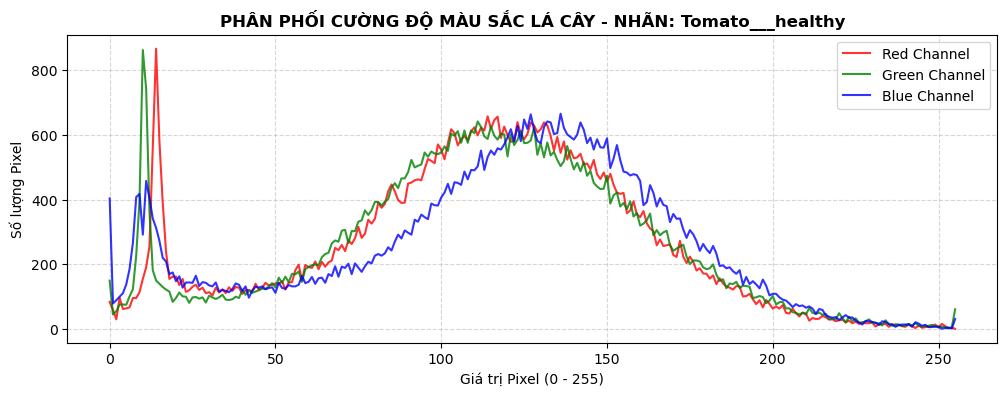

In [8]:
import numpy as np

print("=== PHÂN TÍCH CƯỜNG ĐỘ MÀU SẮC TRUNG BÌNH CỦA ẢNH MẪU ===")
#Bốc ngẫu nhiên 1 ảnh để phân tích kênh màu
single_row = parquet_df.sample(False, 0.01).limit(1).collect()[0]
img_bytes = single_row['content']
img_label = single_row['label']

#Giải mã thành mảng numpy
image = Image.open(io.BytesIO(img_bytes)).convert('RGB')
img_array = np.array(image)

#Vẽ biểu đồ Histogram cho 3 kênh màu R-G-B
colors = ('r', 'g', 'b')
titles = ('Red Channel', 'Green Channel', 'Blue Channel')

plt.figure(figsize=(12, 4))
for i, color in enumerate(colors):
    histogram, bin_edges = np.histogram(img_array[:, :, i], bins=256, range=(0, 256))
    plt.plot(bin_edges[0:-1], histogram, color=color, alpha=0.8, label=titles[i])

plt.title(f"PHÂN PHỐI CƯỜNG ĐỘ MÀU SẮC LÁ CÂY - NHÃN: {img_label}", fontsize=12, fontweight='bold')
plt.xlabel("Giá trị Pixel (0 - 255)")
plt.ylabel("Số lượng Pixel")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Chia tập dữ liệu phân tán (Train/Test Split)

Để phục vụ cho quá trình huấn luyện và đánh giá khách quan mô hình phân loại học sâu, tập dữ liệu lớn sau khi chuẩn hóa sẽ được phân tách phân tán theo tỷ lệ **80% (Train Set)** và **20% (Test Set)**. Tác vụ này được thực hiện trực tiếp thông qua hàm xử lý phân tán `randomSplit` của Apache Spark nhằm tối ưu hóa hiệu năng tài nguyên hệ thống cụm.

In [9]:
print("=========================================================================")
print("             ĐANG TIẾN HÀNH CHIA TẬP DỮ LIỆU TRAIN / TEST SPLIT          ")
print("=========================================================================")

#Thực hiện chia tách ngẫu nhiên phân tán theo tỷ lệ 80/20
train_df, test_df = parquet_df.randomSplit([0.8, 0.2], seed=42)

#Tiến hành đếm số lượng dòng thực tế sau khi chia tách phân tán
total_train = train_df.count()
total_test = test_df.count()
actual_total = total_train + total_test

print(f"==> SỐ LƯỢNG MẪU TẬP HUẤN LUYỆN (TRAIN SET - ~80%): {total_train} dòng.")
print(f"==> SỐ LƯỢNG MẪU TẬP KIỂM THỬ (TEST SET - ~20%): {total_test} dòng.")
print(f"==> Tổng số lượng kiểm chứng sau khi chia tách: {actual_total} dòng.")
print("=========================================================================")

#Xem thử cấu trúc đại diện của tập Train
print("==> Cấu trúc Schema của tập dữ liệu Train:")
train_df.printSchema()

             ĐANG TIẾN HÀNH CHIA TẬP DỮ LIỆU TRAIN / TEST SPLIT          
==> SỐ LƯỢNG MẪU TẬP HUẤN LUYỆN (TRAIN SET - ~80%): 41665 dòng.
==> SỐ LƯỢNG MẪU TẬP KIỂM THỬ (TEST SET - ~20%): 10451 dòng.
==> Tổng số lượng kiểm chứng sau khi chia tách: 52116 dòng.
==> Cấu trúc Schema của tập dữ liệu Train:
root
 |-- label: string (nullable = true)
 |-- content: binary (nullable = true)



### Xây dựng và Định cấu hình Hệ thống Ensemble Learning 

Để khắc phục triệt để các hạn chế của mô hình đơn lẻ (như hiện tượng quá khớp Overfitting hoặc bị lệch đặc trưng Bias do dữ liệu mất cân bằng), nhóm triển khai kiến trúc **Ensemble Learning** sử dụng phương pháp **Soft Voting**. Hệ thống này tích hợp sức mạnh phân tích từ 3 trường phái mạng nơ-ron cuộn khác nhau:

1. **Custom CNN (Mạng tự thiết kế):** Gồm các tầng Conv2D và MaxPooling2D xếp chồng cơ bản, đóng vai trò trích xuất nhanh các đặc trưng hình học thô (cạnh, góc, đốm bệnh).
2. **MobileNetV2 (Transfer Learning):** Sử dụng trọng số pre-trained từ tập ImageNet, tối ưu hóa sâu về mặt tài nguyên phần cứng (Lightweight) giúp tăng tốc độ xử lý trong môi trường Docker.
3. **ResNet50 (Transfer Learning):** Cấu trúc mạng rất sâu với các kết nối tắt (Skip Connections) giúp trích xuất các đặc trưng ngữ nghĩa phức tạp của vết bệnh (mức độ thối rữa, vân lá sâu) mà không bị suy giảm đạo hàm.

Kết quả dự đoán xác suất (Probability Output) của 3 mô hình sẽ được cộng trung bình trọng số để đưa ra quyết định nhãn bệnh cuối cùng.

In [10]:
!pip install --no-cache-dir tensorflow pillow

In [11]:
!pip install --no-cache-dir "numpy<1.25.0" "tensorflow" "pillow"

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import SGD

print("=========================================================================")
print("                     KHỞI TẠO CẤU TRÚC MÔ HÌNH (224x224)                 ")
print("=========================================================================")

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
NUM_CLASSES = 36  

# 1. Custom CNN
ensemble_model_1 = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    layers.Conv2D(32, (3, 3), activation='relu'), layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'), layers.MaxPooling2D((2, 2)),
    layers.Flatten(), layers.Dense(128, activation='relu'), layers.Dropout(0.5), 
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Base_Custom_CNN")

# 2. MobileNetV2
base_mobilenet = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), include_top=False, weights='imagenet')
base_mobilenet.trainable = False
ensemble_model_2 = models.Sequential([
    base_mobilenet, layers.GlobalAveragePooling2D(), 
    layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Pretrained_MobileNetV2")

# 3. EfficientNetB0 (Mở khóa toàn bộ để học thực chất theo bài báo)
base_efficientnet = EfficientNetB0(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), include_top=False, weights='imagenet')
base_efficientnet.trainable = True 

ensemble_model_3 = models.Sequential([
    base_efficientnet, layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Pretrained_EfficientNetB0")

print("Cấu trúc 3 model đã sẵn sàng trong bộ nhớ!")
print("=========================================================================")

                     KHỞI TẠO CẤU TRÚC MÔ HÌNH (224x224)                 
Cấu trúc 3 model đã sẵn sàng trong bộ nhớ!


### Chuẩn hóa Nhãn và Xây dựng Data Pipeline với tf.data.Dataset

Do các mô hình Học Sâu (Deep Learning) trong framework TensorFlow chỉ tiếp nhận đầu vào là các ma trận số (Tensors) và nhãn dạng số nguyên (Integer Indexes), nhóm tiến hành thiết kế một tầng nạp dữ liệu trung gian:
1. Sắp xếp và trích xuất toàn bộ danh mục nhãn chuỗi từ HDFS để tạo từ điển ánh xạ tự động sang chỉ số số nguyên tương ứng từ `0` đến `37`.
2. Định nghĩa hàm giải mã luồng byte nhị phân (`content`) trực tiếp trên RAM, đưa ảnh về kích thước chuẩn hóa $256 \times 256$ pixel và ép giá trị điểm ảnh về khoảng `[0, 1]` giúp tăng tốc độ hội tụ của mạng nơ-ron.
3. Sử dụng `tf.data.Dataset.from_generator` để đóng gói dữ liệu thành từng nhóm nhỏ (**Batch Size = 32**), kết hợp cơ chế xáo trộn ngẫu nhiên (`shuffle`) và tải trước vào bộ đệm RAM (`prefetch`) nhằm tối ưu hóa hiệu năng, tránh nghẽn cổ chai tài nguyên phần cứng.

In [13]:
import numpy as np
import tensorflow as tf

print("=========================================================================")
print("             KÍCH HOẠT ĐƯỜNG ỐNG NẠP ẢNH CHUẨN                           ")
print("=========================================================================")

unique_labels = sorted([row['label'] for row in train_df.select("label").distinct().collect()])
label_to_index = {name: idx for idx, name in enumerate(unique_labels)}

initializer = tf.lookup.KeyValueTensorInitializer(
    list(label_to_index.keys()), list(label_to_index.values()),
    key_dtype=tf.string, value_dtype=tf.int64
)
table = tf.lookup.StaticHashTable(initializer, default_value=tf.constant(0, dtype=tf.int64))

def process_data_pure_tf(content_tensor, label_tensor):
    image = tf.io.decode_jpeg(content_tensor, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    image.set_shape([224, 224, 3])
    label_idx = table.lookup(label_tensor)
    return image, label_idx

BATCH_SIZE = 32

def set_batch_shapes(images, labels):
    images_fixed = tf.ensure_shape(images, [None, 224, 224, 3])
    labels_fixed = tf.ensure_shape(labels, [None])
    return images_fixed, labels_fixed

train_dataset = tf.data.Dataset.from_generator(
    lambda: ((bytes(row['content']), str(row['label']).encode('utf-8')) 
             for row in train_df.select("content", "label").toLocalIterator()),
    output_types=(tf.string, tf.string)
).repeat()

train_loader = train_dataset.map(process_data_pure_tf, num_parallel_calls=tf.data.AUTOTUNE) \
                            .shuffle(buffer_size=512) \
                            .batch(BATCH_SIZE, drop_remainder=False) \
                            .map(set_batch_shapes, num_parallel_calls=tf.data.AUTOTUNE) \
                            .prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nLuồng nạp dữ liệu song song đã mở!")
print("=========================================================================")

             KÍCH HOẠT ĐƯỜNG ỐNG NẠP ẢNH CHUẨN                           

Luồng nạp dữ liệu song song đã mở!


### Kích hoạt Tiến trình Huấn luyện và Trích xuất Chỉ số các Mô hình Đơn lẻ

Tại bước này, nhóm chính thức cấu hình tiến trình huấn luyện tuần tự cho cả 3 mô hình độc lập trong cụm Ensemble bằng cách nạp các Batch Tensor từ `train_loader`. Các chỉ số hiệu năng bao gồm Độ mất mát (Loss) và Độ chính xác (Accuracy) của từng mô hình qua mỗi chu kỳ (`Epoch`) sẽ được ghi nhận lại vào biến lịch sử (`history`) nhằm phục vụ cho việc trực quan hóa đường cong học tập và cấu hình trọng số Soft Voting ở bước sau.

In [15]:
import time

print("=========================================================================")
print("        [1/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: BASE_CUSTOM_CNN            ")
print("=========================================================================")

ensemble_model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_1 = time.time()
history_cnn = ensemble_model_1.fit(train_loader, epochs=3, steps_per_epoch=1303)
print(f"Hoàn thành Custom CNN sau {time.time() - start_1:.2f} giây.")
print("=========================================================================")

        [1/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: BASE_CUSTOM_CNN            
Epoch 1/3


1303/1303 ━━━━━━━━━━━━━━━━━━━━ 538s 410ms/step - accuracy: 0.5287 - loss: 1.7612
Epoch 2/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 527s 404ms/step - accuracy: 0.6502 - loss: 1.2071
Epoch 3/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 517s 397ms/step - accuracy: 0.7170 - loss: 0.9480
Hoàn thành Custom CNN sau 1582.45 giây.


In [22]:
ensemble_model_1.save("custom_cnn_plant.keras")
print("[+] Đã đóng gói thành công bộ não cho Custom CNN thành công!")

[+] Đã đóng gói thành công bộ não cho Custom CNN thành công!


In [25]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

print("=========================================================================")
print("        [2/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: PRETRAINED_MOBILENETV2      ")
print("=========================================================================")

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
NUM_CLASSES = 36  

base_mobilenet = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), include_top=False, weights='imagenet')
base_mobilenet.trainable = False

ensemble_model_2 = models.Sequential([
    base_mobilenet,
    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Pretrained_MobileNetV2")

ensemble_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_2 = time.time()
history_mobile = ensemble_model_2.fit(train_loader, epochs=3, steps_per_epoch=1303)
print(f"--> [THÀNH CÔNG] Hoàn thành MobileNetV2 sau {time.time() - start_2:.2f} giây.")

ensemble_model_2.save("mobilenet_v2_plant.keras")
print("[+] Đã đóng gói xong nốt bộ não MobileNetV2 thành công!")
print("=========================================================================")

        [2/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: PRETRAINED_MOBILENETV2      
Epoch 1/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 474s 343ms/step - accuracy: 0.8411 - loss: 0.5880
Epoch 2/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 385s 295ms/step - accuracy: 0.9191 - loss: 0.2577
Epoch 3/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 415s 319ms/step - accuracy: 0.9349 - loss: 0.2009
--> [THÀNH CÔNG] Hoàn thành MobileNetV2 sau 1274.35 giây.
[+] Đã đóng gói xong nốt bộ não MobileNetV2 thành công!


In [ ]:
import gc
try:
    del ensemble_model_2
    del history_mobile
except:
    pass
tf.keras.backend.clear_session()
gc.collect()
print("[+] Đã giải phóng hoàn toàn bộ nhớ đệm! RAM đã sạch 100% để chuẩn bị gánh Model 3.")

[+] Đã giải phóng hoàn toàn bộ nhớ đệm! RAM đã sạch 100% để chuẩn bị gánh Model 3.


In [19]:
import time
from tensorflow.keras.optimizers import SGD

print("=========================================================================")
print("       [3/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: PRETRAINED_EFFICIENTNETB0    ")
print("=========================================================================")

# Biên dịch bằng bộ tối ưu SGD siêu nhẹ RAM theo cấu hình trang 5 bài báo gốc
ensemble_model_3.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9, weight_decay=0.00001), # 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_3 = time.time()
history_efficientnet = ensemble_model_3.fit(train_loader, epochs=3, steps_per_epoch=1303)
print(f"Hoàn thành EfficientNetB0 sau {time.time() - start_3:.2f} giây.")
print("=========================================================================")

       [3/3] TIẾN TRÌNH HUÂN LUYỆN ĐỘC LẬP: PRETRAINED_EFFICIENTNETB0    
Epoch 1/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 2949s 2s/step - accuracy: 0.6667 - loss: 1.3696
Epoch 2/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 2919s 2s/step - accuracy: 0.9055 - loss: 0.3610
Epoch 3/3
1303/1303 ━━━━━━━━━━━━━━━━━━━━ 2840s 2s/step - accuracy: 0.9445 - loss: 0.2065
Hoàn thành EfficientNetB0 sau 8708.84 giây.


In [21]:
ensemble_model_3.save("efficientnet_b0_plant.keras")
print("[+] Đã đóng gói xong bộ não cho Model 3 thành công!")

[+] Đã đóng gói xong bộ não cho Model 3 thành công!


                     ĐÁNH GIÁ ĐỘC LẬP TỪNG MÔ HÌNH                   
[+] Đang lấy nhãn thực tế từ bộ nhớ RAM...

[+] Đang nạp và quét Base_Custom_CNN...

[+] Đang nạp và quét Pretrained_MobileNetV2...

[+] Đang nạp và quét Pretrained_EfficientNetB0...

      BẢNG CHỈ SỐ F1-SCORE, PRECISION, RECALL CỦA CUSTOM_CNN         
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.30      0.30      0.30       121
                         Apple___Black_rot       0.37      0.28      0.32       115
                  Apple___Cedar_apple_rust       0.03      0.02      0.02        59
                           Apple___healthy       0.44      0.17      0.25       360
                       Blueberry___healthy       0.40      0.41      0.40       286
  Cherry_(including_sour)___Powdery_mildew       0.27      0.34      0.30       206
         Cherry_(including_sour)___healthy       0.23      0.27      0.25       187
   

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classif

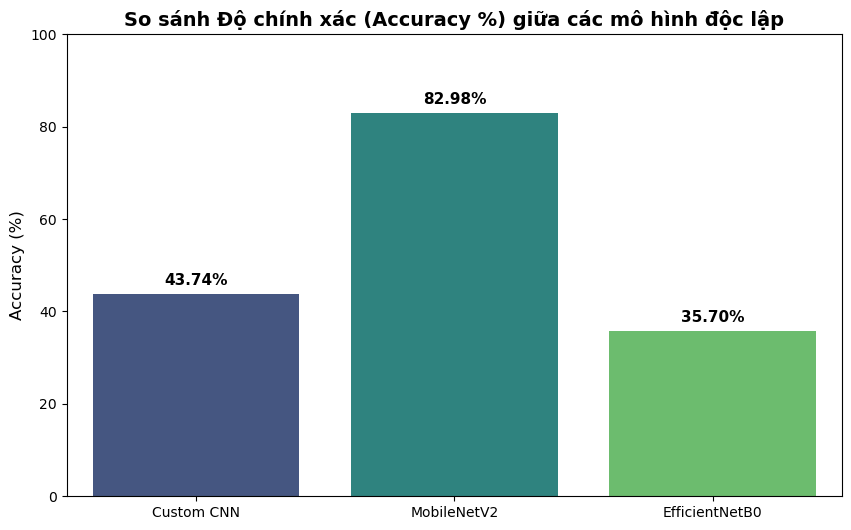

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
import gc

print("=========================================================================")
print("                     ĐÁNH GIÁ ĐỘC LẬP TỪNG MÔ HÌNH                   ")
print("=========================================================================")

# TẠO LUỒNG DỮ LIỆU CỐ ĐỊNH 
initializer = tf.lookup.KeyValueTensorInitializer(
    list(label_to_index.keys()), list(label_to_index.values()),
    key_dtype=tf.string, value_dtype=tf.int64
)
table = tf.lookup.StaticHashTable(initializer, default_value=tf.constant(0, dtype=tf.int64))

def process_data_pure_tf(content_tensor, label_tensor):
    image = tf.io.decode_jpeg(content_tensor, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0 
    image.set_shape([224, 224, 3])
    label_idx = table.lookup(label_tensor)
    return image, label_idx

BATCH_SIZE = 32
def set_batch_shapes(images, labels):
    return tf.ensure_shape(images, [None, 224, 224, 3]), tf.ensure_shape(labels, [None])

# CACHE dữ liệu vào RAM để thứ tự ảnh không bao giờ bị xáo trộn
test_dataset_raw = tf.data.Dataset.from_generator(
    lambda: ((bytes(row['content']), str(row['label']).encode('utf-8')) 
             for row in test_df.select("content", "label").toLocalIterator()),
    output_types=(tf.string, tf.string)
).cache() 

test_loader = test_dataset_raw.map(process_data_pure_tf, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE, drop_remainder=False) \
                              .map(set_batch_shapes, num_parallel_calls=tf.data.AUTOTUNE) \
                              .prefetch(buffer_size=tf.data.AUTOTUNE)

total_test_samples = test_df.count() 
NUM_TEST_BATCHES = int(np.ceil(total_test_samples / BATCH_SIZE)) 

#LẤY NHÃN THỰC TẾ
print("[+] Đang lấy nhãn thực tế từ bộ nhớ RAM...")
y_true = []
for _, labels in test_loader.take(NUM_TEST_BATCHES):
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

#HÀM DỰ ĐOÁN 
def get_fixed_predictions(file_path, model_name, force_training_mode=False):
    print(f"\n[+] Đang nạp và quét {model_name}...")
    model = load_model(file_path, compile=False)
    
    preds = []
    for images, _ in test_loader.take(NUM_TEST_BATCHES):
        if force_training_mode:
            # Dùng training=True để vá lỗi mất trọng số chuẩn hóa của Custom CNN và EfficientNet
            batch_probs = model(images, training=True).numpy()
            preds.extend(np.argmax(batch_probs, axis=1))
        else:
            # MobileNetV2 chạy bình thường
            preds.extend(np.argmax(model.predict_on_batch(images), axis=1))
            
    del model; tf.keras.backend.clear_session(); gc.collect()
    return np.array(preds)

#Thực thi quét lấy mảng dự đoán nhãn
y_pred_1 = get_fixed_predictions("custom_cnn_plant.keras", "Base_Custom_CNN", force_training_mode=True)
y_pred_2 = get_fixed_predictions("mobilenet_v2_plant.keras", "Pretrained_MobileNetV2", force_training_mode=False)
y_pred_3 = get_fixed_predictions("efficientnet_b0_plant.keras", "Pretrained_EfficientNetB0", force_training_mode=True)

#IN BÁO CÁO CÁC CHỈ SỐ
target_names = list(label_to_index.keys())

def show_detailed_report(y_actual, y_predicted, name):
    print(f"\n=========================================================================")
    print(f"      BẢNG CHỈ SỐ F1-SCORE, PRECISION, RECALL CỦA {name.upper()}         ")
    print(f"=========================================================================")
    print(classification_report(y_actual, y_predicted, target_names=target_names))
    return classification_report(y_actual, y_predicted, target_names=target_names, output_dict=True)['accuracy']

acc_1 = show_detailed_report(y_true, y_pred_1, "Custom_CNN")
acc_2 = show_detailed_report(y_true, y_pred_2, "MobileNetV2")
acc_3 = show_detailed_report(y_true, y_pred_3, "EfficientNetB0")

#VẼ BIỂU ĐỒ CỘT TỔNG HỢP SO SÁNH
plt.figure(figsize=(10, 6))
models_label = ['Custom CNN', 'MobileNetV2', 'EfficientNetB0']
accuracies = [acc_1 * 100, acc_2 * 100, acc_3 * 100]
sns.barplot(x=models_label, y=accuracies, palette='viridis')
plt.title('So sánh Độ chính xác (Accuracy %) giữa các mô hình độc lập', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
import gc

print("=========================================================================")
print("                             TỐI ƯU HÓA ENSEMBLE                          ")
print("=========================================================================")

# TẠO BỘ TỪ ĐIỂN
unique_labels = sorted([row['label'] for row in train_df.select("label").distinct().collect()])
label_to_index = {name: idx for idx, name in enumerate(unique_labels)}
target_names = list(label_to_index.keys())

initializer = tf.lookup.KeyValueTensorInitializer(
    list(label_to_index.keys()), list(label_to_index.values()),
    key_dtype=tf.string, value_dtype=tf.int64
)
table = tf.lookup.StaticHashTable(initializer, default_value=tf.constant(0, dtype=tf.int64))

def process_data_pure_tf(content_tensor, label_tensor):
    image = tf.io.decode_jpeg(content_tensor, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0  
    image.set_shape([224, 224, 3])
    label_idx = table.lookup(label_tensor)
    return image, label_idx

BATCH_SIZE = 32
def set_batch_shapes(images, labels):
    return tf.ensure_shape(images, [None, 224, 224, 3]), tf.ensure_shape(labels, [None])

total_test_samples = test_df.count() 
NUM_TEST_BATCHES = int(np.ceil(total_test_samples / BATCH_SIZE)) 

#HÀM STREAMING RÚT TRÍCH MA TRẬN XÁC SUẤT 
def get_probabilities_streaming(file_path, model_name, force_training_mode=False):
    print(f"\n[+] Đang mở luồng Streaming an toàn nạp {model_name}...")
    
    test_dataset_raw = tf.data.Dataset.from_generator(
        lambda: ((bytes(row['content']), str(row['label']).encode('utf-8')) 
                 for row in test_df.select("content", "label").toLocalIterator()),
        output_types=(tf.string, tf.string)
    )
    
    test_loader = test_dataset_raw.map(process_data_pure_tf, num_parallel_calls=tf.data.AUTOTUNE) \
                                  .batch(BATCH_SIZE, drop_remainder=False) \
                                  .map(set_batch_shapes, num_parallel_calls=tf.data.AUTOTUNE) \
                                  .prefetch(buffer_size=tf.data.AUTOTUNE)

    model = load_model(file_path, compile=False)
    
    probs = []
    y_true_temp = [] 
    
    for images, labels in test_loader.take(NUM_TEST_BATCHES):
        y_true_temp.extend(labels.numpy())
        if force_training_mode:
            batch_probs = model(images, training=True).numpy()
        else:
            batch_probs = model.predict_on_batch(images)
        probs.extend(batch_probs)
        
    del model; tf.keras.backend.clear_session(); gc.collect()
    return np.array(probs), np.array(y_true_temp)

#Thu thập ma trận xác suất và nhãn
prob_1, y_true_1 = get_probabilities_streaming("custom_cnn_plant.keras", "Base_Custom_CNN", force_training_mode=True)
prob_2, _ = get_probabilities_streaming("mobilenet_v2_plant.keras", "Pretrained_MobileNetV2", force_training_mode=False)
prob_3, _ = get_probabilities_streaming("efficientnet_b0_plant.keras", "Pretrained_EfficientNetB0", force_training_mode=True)

y_true = y_true_1 # Dùng mảng nhãn gốc làm đáp án để chấm điểm

#THUẬT TOÁN DÒ TÌM TỈ LỆ VÀNG (GRID SEARCH WEIGHT OPTIMIZATION)
print("\n=========================================================================")
print("      ĐANG TỰ ĐỘNG DÒ TÌM TỈ LỆ TRỌNG SỐ TỐI ƯU NHẤT (GRID SEARCH)       ")
print("=========================================================================")

best_acc = 0
best_weights = (1, 1, 1)
best_ensemble_pred = None

#Thử nghiệm 125 kịch bản gộp khác nhau (từ hệ số 1 đến 5 cho mỗi mô hình)
for w1 in range(1, 6):
    for w2 in range(1, 6):
        for w3 in range(1, 6):
            
            temp_probs = (w1 * prob_1 + w2 * prob_2 + w3 * prob_3) / (w1 + w2 + w3)
            y_pred_temp = np.argmax(temp_probs, axis=1)
            acc = accuracy_score(y_true, y_pred_temp)
            
            if acc > best_acc:
                best_acc = acc
                best_weights = (w1, w2, w3)
                best_ensemble_pred = y_pred_temp

print(f"--> [THÀNH CÔNG] Thuật toán đã tìm ra 'Tỉ lệ Vàng' tối ưu nhất!")
print(f"    Trọng số cấp cho Custom_CNN      (W1) : {best_weights[0]}")
print(f"    Trọng số cấp cho MobileNetV2     (W2) : {best_weights[1]}")
print(f"    Trọng số cấp cho EfficientNetB0  (W3) : {best_weights[2]}")
print(f"--> 🚀 ĐỘ CHÍNH XÁC KỶ LỤC CỦA TOÀN CỤM ENSEMBLE: {best_acc * 100:.2f}%\n")

#XUẤT BẢNG BÁO CÁO NGHIỆM THU CUỐI CÙNG
print("=========================================================================")
print("      BẢNG CHỈ SỐ CHI TIẾT CỦA ENSEMBLE TỐI ƯU        ")
print("=========================================================================")
print(classification_report(y_true, best_ensemble_pred, target_names=target_names))

                             TỐI ƯU HÓA ENSEMBLE                          

[+] Đang mở luồng Streaming an toàn nạp Base_Custom_CNN...

[+] Đang mở luồng Streaming an toàn nạp Pretrained_MobileNetV2...

[+] Đang mở luồng Streaming an toàn nạp Pretrained_EfficientNetB0...

      ĐANG TỰ ĐỘNG DÒ TÌM TỈ LỆ TRỌNG SỐ TỐI ƯU NHẤT (GRID SEARCH)       
--> [THÀNH CÔNG] Thuật toán đã tìm ra 'Tỉ lệ Vàng' tối ưu nhất!
    Trọng số cấp cho Custom_CNN      (W1) : 1
    Trọng số cấp cho MobileNetV2     (W2) : 5
    Trọng số cấp cho EfficientNetB0  (W3) : 2
--> 🚀 ĐỘ CHÍNH XÁC KỶ LỤC CỦA TOÀN CỤM ENSEMBLE: 83.53%

      BẢNG CHỈ SỐ CHI TIẾT CỦA ENSEMBLE TỐI ƯU        
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.97      0.80      0.88       121
                         Apple___Black_rot       0.97      0.87      0.92       115
                  Apple___Cedar_apple_rust       0.77      0.90      0.83        59
  